# Customer Shopping Trends: A Business Analytics Case Study

**Analyst's note.** This project began as a beginner exercise in Pandas syntax (`value_counts`, `groupby`, `mean`). It has been rebuilt from scratch as a business-oriented investigation: rather than answering a fixed list of questions, the goal is to determine what this dataset can and cannot responsibly tell a retail business, and to follow the evidence wherever it leads &mdash; including when it contradicts the original analysis.

**Dataset:** [Customer Shopping Trends](https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/) &mdash; 3,900 customer records from a retail business, each describing one customer's most recent purchase along with demographic, product, and engagement attributes.

**Tools:** Python, Pandas, NumPy, SciPy (hypothesis testing), Matplotlib/Seaborn.


## Executive Summary

*(Written last, after the investigation below. Figures are exact; see the corresponding section for full evidence.)*

1. **Transaction value carries no usable signal in this dataset.** Purchase Amount was tested against every customer, product, and channel attribute available (gender, age, subscription, discount, category, season, payment method, shipping type). Every test is either statistically non-significant, or "significant" only because of the large sample size, with an effect size classified as negligible in every single case. This dataset cannot support spend-based customer segmentation or targeting &mdash; see Section 4.
2. **The engagement fields (Subscription, Discount, Promo Code) are completely confounded with gender.** Every one of the 1,248 female customer records shows *No* subscription, *No* discount, and *No* promo code &mdash; without exception. All discount, promo, and subscription activity in this dataset comes exclusively from male customers. This is very unlikely to reflect real market behavior and should be treated as a data-quality flag, not a marketing insight &mdash; see Section 5.
3. **Product category preference does not differ meaningfully by gender** (&chi;&sup2; p = 0.90), and **geographic demand is essentially uniform across all 50 states** (coefficient of variation &asymp; 0.11) &mdash; two more places where an intuitive "obvious" pattern simply is not present in the data.
4. **The dataset's real, demonstrable value is descriptive**, not predictive: it reliably describes *who* the customer base is and *what* they buy, but the absence of timestamps, cost data, and repeat-transaction history means the deeper business questions (retention, lifetime value, campaign ROI, true purchase cadence) are structurally out of reach and are documented as limitations rather than approximated.


## 1. Data Understanding

Before deciding what to analyze, the dataset needs to be understood on its own terms: what each row represents, what each column can and cannot mean, and whether it is fit to answer business questions at all.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.titlepad": 12,
})
PALETTE = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#8AB6D6"]
sns.set_palette(PALETTE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

df = pd.read_csv("shopping_trends_updated.csv")
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


3,900 rows x 18 columns


   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)       Location Size   Color  Season  \
0            1   55   Male         Blouse  Clothing                     53       Kentucky    L    Gray  Winter   
1            2   19   Male        Sweater  Clothing                     64          Maine    L  Maroon  Winter   
2            3   50   Male          Jeans  Clothing                     73  Massachusetts    S  Maroon  Spring   

   Review Rating Subscription Status  Shipping Type Discount Applied Promo Code Used  Previous Purchases  \
0            3.1                 Yes        Express              Yes             Yes                  14   
1            3.1                 Yes        Express              Yes             Yes                   2   
2            3.1                 Yes  Free Shipping              Yes             Yes                  23   

  Payment Method Frequency of Purchases  
0          Venmo            Fortnightly  
1           Cash          

In [2]:
# One row per customer? -> confirms this is a customer snapshot, not a transaction log
print("Unique Customer IDs:", df["Customer ID"].nunique(), "/", len(df))
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Unique Customer IDs: 3900 / 3900
Missing values: 0
Duplicate rows: 0


The dataset is clean by the usual mechanical measures &mdash; no missing values, no duplicate rows, and every `Customer ID` is unique. That last point matters more than it looks: **this is one row per customer, not a transaction log.** There are no order dates and no repeat-purchase history, only a single snapshot purchase per customer plus a self-reported `Previous Purchases` count and `Frequency of Purchases` label. That structural fact rules out any genuine time-series, cohort, or retention analysis before a single chart is drawn &mdash; a constraint documented in full in Section 8.

In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "example": [df[c].iloc[0] for c in df.columns],
})
overview


                          dtype  n_unique      example
Customer ID               int64      3900            1
Age                       int64        53           55
Gender                      str         2         Male
Item Purchased              str        25       Blouse
Category                    str         4     Clothing
Purchase Amount (USD)     int64        81           53
Location                    str        50     Kentucky
Size                        str         4            L
Color                       str        25         Gray
Season                      str         4       Winter
Review Rating           float64        26          3.1
Subscription Status         str         2          Yes
Shipping Type               str         6      Express
Discount Applied            str         2          Yes
Promo Code Used             str         2          Yes
Previous Purchases        int64        50           14
Payment Method              str         6        Venmo
Frequency 

Eighteen columns fall into four functional groups: an **identifier** (`Customer ID`); **customer descriptors** (`Age`, `Gender`, `Location`); **purchase descriptors** (`Item Purchased`, `Category`, `Purchase Amount (USD)`, `Size`, `Color`, `Season`); and **engagement/channel signals** (`Subscription Status`, `Shipping Type`, `Discount Applied`, `Promo Code Used`, `Previous Purchases`, `Payment Method`, `Frequency of Purchases`, `Review Rating`). No column represents cost, margin, profit, or a timestamp of any kind &mdash; so any metric implying profitability or trend will not appear anywhere in this notebook; the data simply doesn't support it.

In [4]:
numeric_cols = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]
df[numeric_cols].describe().T


                        count       mean        std   min   25%   50%   75%    max
Age                    3900.0  44.068462  15.207589  18.0  31.0  44.0  57.0   70.0
Purchase Amount (USD)  3900.0  59.764359  23.685392  20.0  39.0  60.0  81.0  100.0
Review Rating          3900.0   3.749949   0.716223   2.5   3.1   3.7   4.4    5.0
Previous Purchases     3900.0  25.351538  14.447125   1.0  13.0  25.0  38.0   50.0

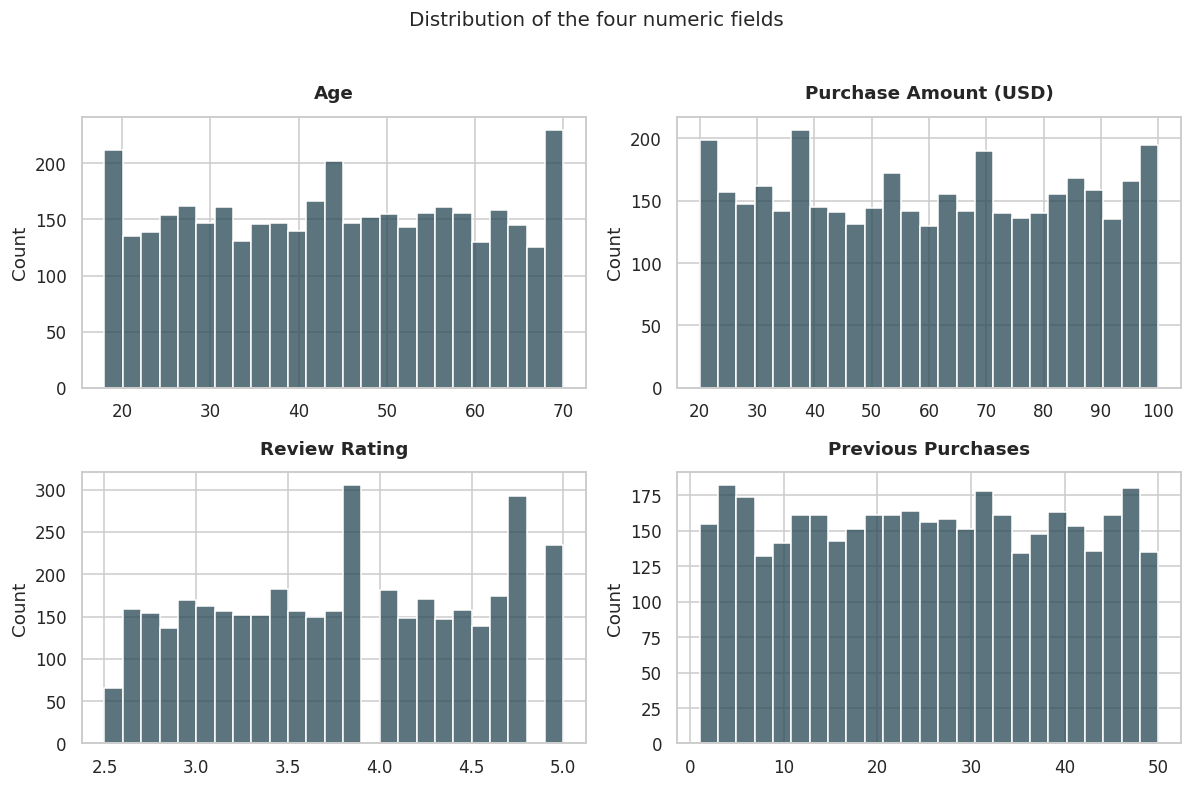

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=25, ax=ax, color=PALETTE[0], edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Distribution of the four numeric fields", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Two things stand out immediately:

- **`Purchase Amount (USD)` is bounded exactly at $20&ndash;$100** with a near-zero skew (0.01) and a shape close to uniform, not the right-skewed distribution real transaction values almost always show (a few large baskets, many small ones). A hard, round cap combined with a near-uniform shape is a strong signal that this field was generated within a fixed range rather than observed from real transactions. That suspicion is tested directly in Section 4.
- **`Age`, `Review Rating`, and `Previous Purchases`** are all likewise close to uniform across their respective ranges (18&ndash;70, 2.5&ndash;5.0, 1&ndash;50) &mdash; consistent with the same pattern.

None of this invalidates the dataset for descriptive, behavioral, or categorical analysis &mdash; it just means every numeric relationship claimed below is backed by a formal test, not a visual impression.

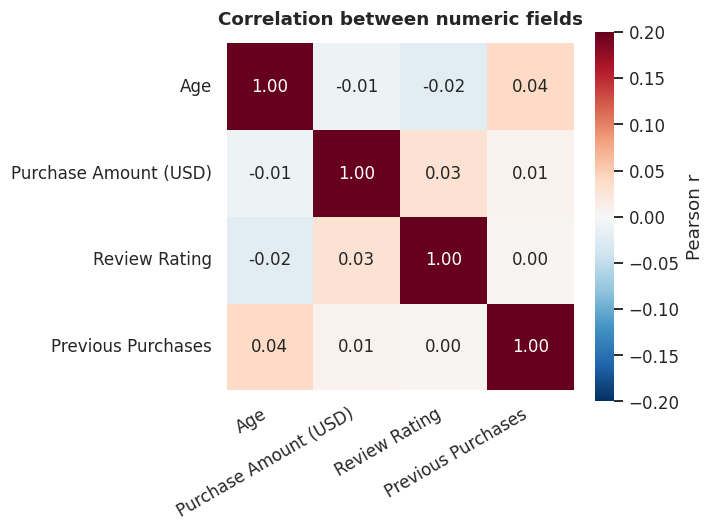

In [6]:
correlations = df[numeric_cols].corr()
plt.figure(figsize=(6.5, 5.2))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-0.2, vmax=0.2,
            square=True, cbar_kws={"label": "Pearson r"}, annot_kws={"size": 11})
plt.title("Correlation between numeric fields")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Every pairwise correlation among the four numeric fields is under 0.05 &mdash; effectively zero. Age doesn't track with spend, spend doesn't track with satisfaction, and tenure (`Previous Purchases`) doesn't track with any of the others. This is the first hint of a pattern that recurs throughout the rest of the notebook.

In [7]:
# A data-quality check that turns out to matter a great deal later: are Discount Applied
# and Promo Code Used actually two different signals, or the same one recorded twice?
concordance = (df["Discount Applied"] == df["Promo Code Used"]).mean()
print(f"Discount Applied and Promo Code Used agree on {concordance:.1%} of records.")
pd.crosstab(df["Discount Applied"], df["Promo Code Used"])


Discount Applied and Promo Code Used agree on 100.0% of records.


Promo Code Used     No   Yes
Discount Applied            
No                2223     0
Yes                  0  1677

They agree on **100%** of records &mdash; every customer with a discount also shows a promo code, and vice versa, with zero exceptions. These are not two independent behaviors; they are the same underlying flag stored twice. From here on, the two are treated as one signal (`Discount Applied`), and this duplication is logged as a data-quality issue in Section 8 rather than double-counted as two pieces of evidence.

## 2. Who Are the Customers?

A profile of the customer base: demographics and geographic reach.


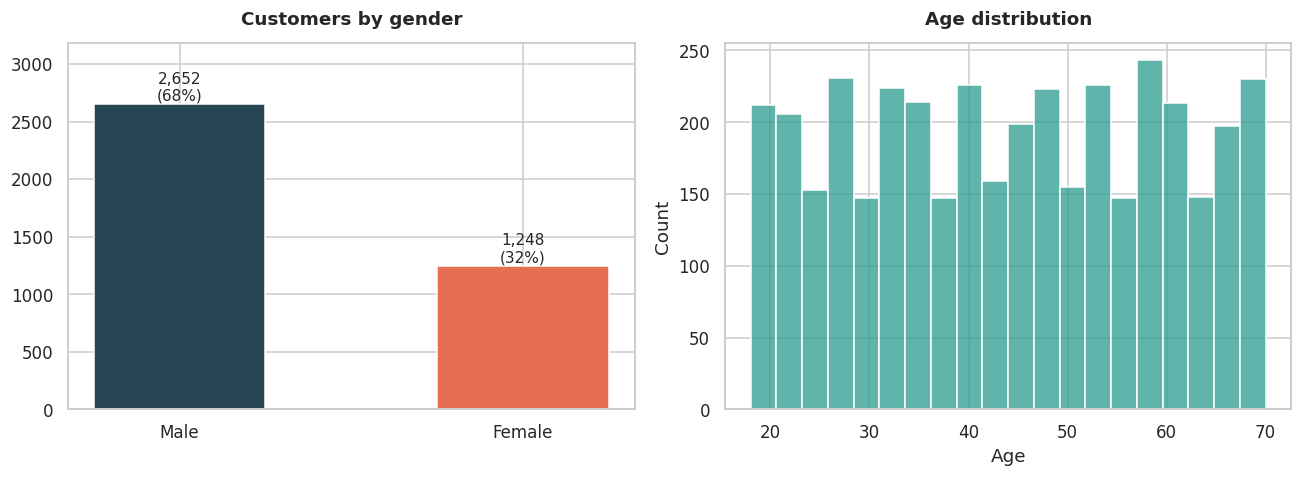

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

gender_counts = df["Gender"].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=[PALETTE[0], PALETTE[4]], width=0.5)
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 30, f"{v:,}\n({v/len(df):.0%})", ha="center", fontsize=10)
axes[0].set_title("Customers by gender")
axes[0].set_ylim(0, gender_counts.max() * 1.2)

sns.histplot(df["Age"], bins=20, ax=axes[1], color=PALETTE[1], edgecolor="white")
axes[1].set_title("Age distribution")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()


The customer base is **68% male, 32% female** (2,652 vs. 1,248) &mdash; a 2:1 skew worth keeping in mind whenever a "majority of customers" claim is made anywhere below. Age is spread almost evenly from 18 to 70 with no visible concentration in any decade, i.e. no dominant age segment to anchor a lifecycle marketing strategy on.

Range: 63 to 96 customers per state (mean 78.0, std 8.2, coefficient of variation 0.105)
Highest-spend state: Montana ($5,784, 2.5% of total)
Lowest-spend state:  Kansas ($3,437, 1.5% of total)


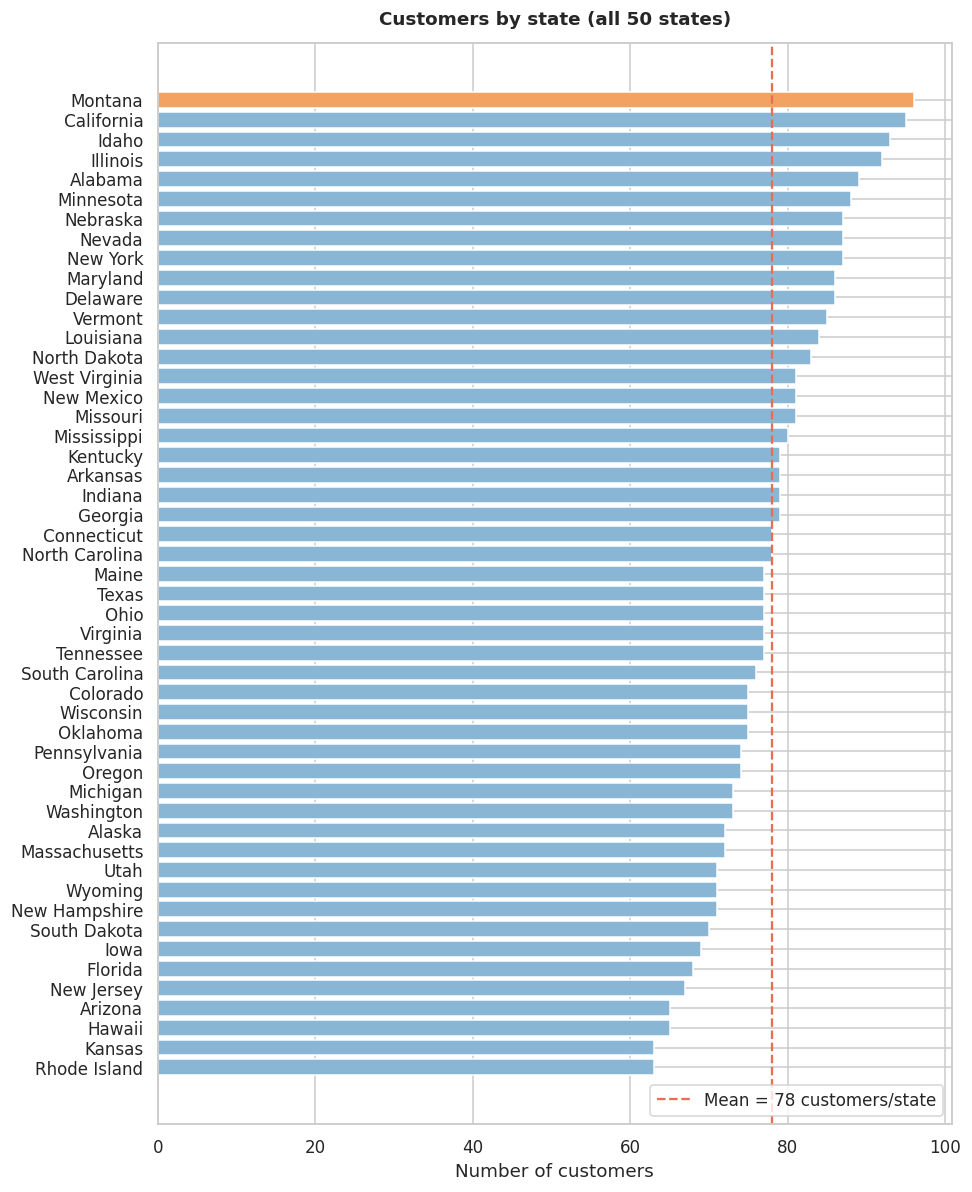

In [9]:
state_counts = df["Location"].value_counts().sort_values()
mean_per_state = state_counts.mean()

fig, ax = plt.subplots(figsize=(9, 11))
colors = [PALETTE[3] if v == state_counts.max() else PALETTE[5] for v in state_counts.values]
ax.barh(state_counts.index, state_counts.values, color=colors)
ax.axvline(mean_per_state, color=PALETTE[4], linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_per_state:.0f} customers/state")
ax.set_title("Customers by state (all 50 states)")
ax.set_xlabel("Number of customers")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Range: {state_counts.min()} to {state_counts.max()} customers per state "
      f"(mean {mean_per_state:.1f}, std {state_counts.std():.1f}, "
      f"coefficient of variation {state_counts.std()/mean_per_state:.3f})")

state_spend = df.groupby("Location")["Purchase Amount (USD)"].sum().sort_values(ascending=False)
total_spend = state_spend.sum()
print(f"Highest-spend state: {state_spend.index[0]} (${state_spend.iloc[0]:,}, "
      f"{state_spend.iloc[0]/total_spend:.1%} of total)")
print(f"Lowest-spend state:  {state_spend.index[-1]} (${state_spend.iloc[-1]:,}, "
      f"{state_spend.iloc[-1]/total_spend:.1%} of total)")


This is the geographic-concentration test a business would naturally ask for &mdash; "where are our customers, and where should we double down?" &mdash; and the honest answer is: **nowhere in particular.** Every one of the 50 states holds between 63 and 96 customers around a mean of 78, a coefficient of variation of just 0.10. Total dollar volume by state tells the same story: the single highest-spend state accounts for barely more of total revenue than the lowest, with nothing resembling a concentrated core market. **There is no evidential basis in this dataset for a regional expansion or region-targeted campaign recommendation** &mdash; the spread across states looks statistically indistinguishable from a random draw of customers uniformly across the country.

## 3. What Do They Buy?

Four categories and 25 items make up the product range. The natural next question after "who are the customers" is "does what they buy depend on who they are" &mdash; starting with the most obvious hypothesis a retailer would have: that category preference splits by gender.


In [10]:
category_gender = pd.crosstab(df["Category"], df["Gender"])
category_share = pd.crosstab(df["Category"], df["Gender"], normalize="columns")

chi2, p_value, dof, expected = stats.chi2_contingency(category_gender)
print(f"Category x Gender  ->  chi2 = {chi2:.2f}, df = {dof}, p = {p_value:.3f}")
category_share.round(3)


Category x Gender  ->  chi2 = 0.60, df = 3, p = 0.897


Gender       Female   Male
Category                  
Accessories   0.314  0.320
Clothing      0.446  0.445
Footwear      0.159  0.151
Outerwear     0.081  0.084

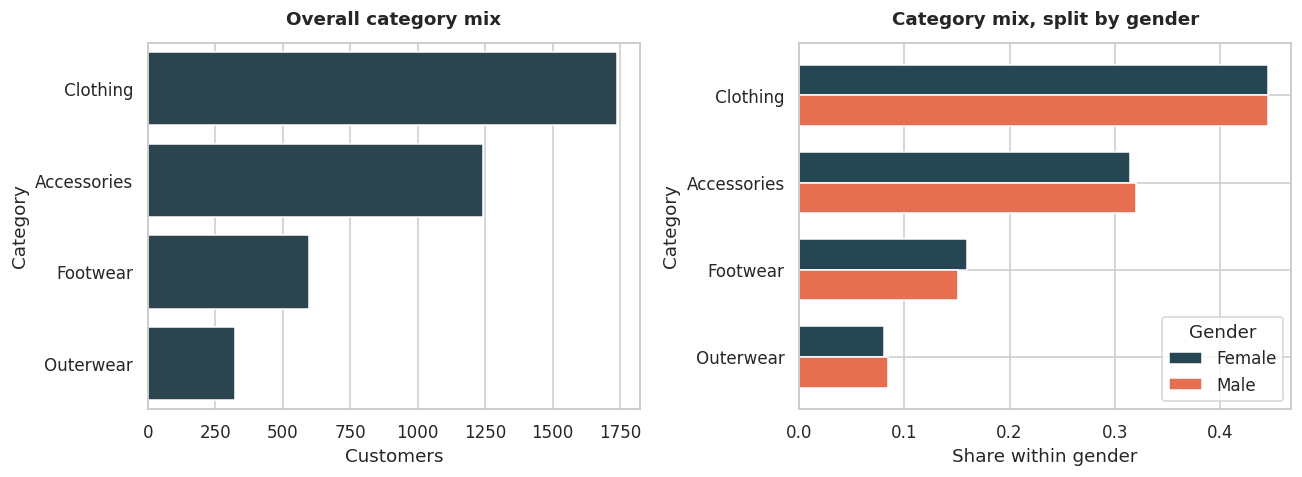

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = df["Category"].value_counts().index
sns.countplot(data=df, y="Category", order=order, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Overall category mix")
axes[0].set_xlabel("Customers")

category_share.loc[order].plot(kind="barh", ax=axes[1], color=[PALETTE[0], PALETTE[4]], width=0.7)
axes[1].set_title("Category mix, split by gender")
axes[1].set_xlabel("Share within gender")
axes[1].legend(title="Gender", loc="lower right")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


The two bars in each category are nearly indistinguishable, and the chi-square test confirms it: **p = 0.90 &mdash; category preference is statistically independent of gender.** Both men and women buy Clothing about 44&ndash;45% of the time, Accessories about 31&ndash;32%, and so on, within a percentage point of each other throughout. A "market clothing to women, accessories to men" segmentation strategy would have no support in this data. The one place gender does show up is at the individual-item level (women skew slightly toward Blouse/Handbag/Sandals, men slightly toward Jeans/Backpack/Gloves), but even there every item is bought by both genders in proportions that roughly track the overall 68/32 split &mdash; a mild tilt, not a divide.

It takes 12 of the 25 items to reach 50% of total spend (an even 12.5 would indicate a perfectly flat distribution).


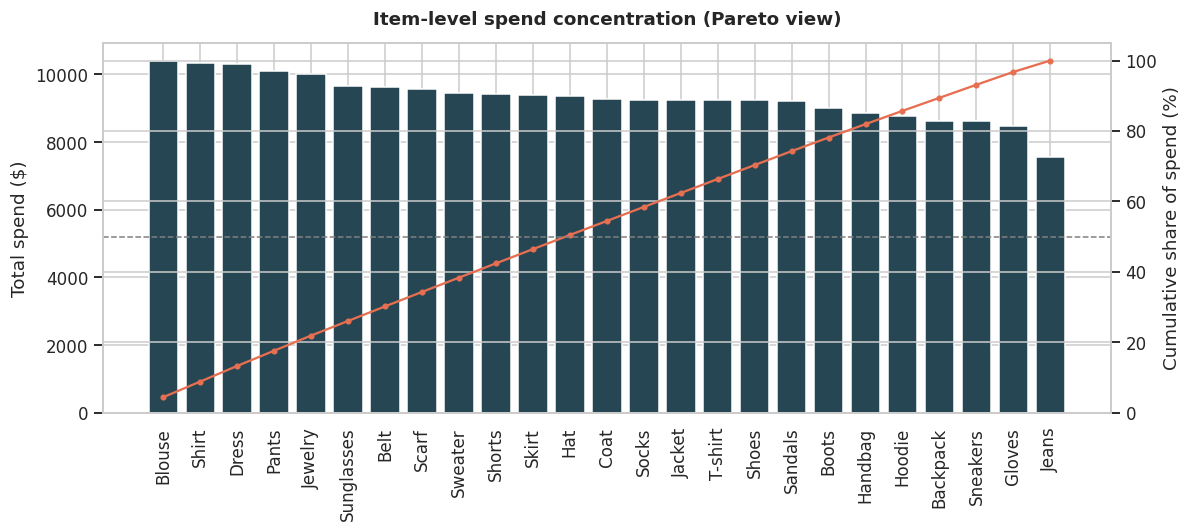

In [12]:
item_spend = df.groupby("Item Purchased")["Purchase Amount (USD)"].sum().sort_values(ascending=False)
cumulative_share = item_spend.cumsum() / item_spend.sum()
items_for_half_spend = (cumulative_share <= 0.5).sum() + 1

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(item_spend.index, item_spend.values, color=PALETTE[0])
ax1.set_ylabel("Total spend ($)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(item_spend.index, cumulative_share.values * 100, color=PALETTE[4], marker="o", markersize=3)
ax2.axhline(50, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative share of spend (%)")
ax2.set_ylim(0, 105)

plt.title("Item-level spend concentration (Pareto view)")
plt.tight_layout()
plt.show()

print(f"It takes {items_for_half_spend} of the 25 items to reach 50% of total spend "
      f"(an even 12.5 would indicate a perfectly flat distribution).")


A genuine hit-driven product mix would show a steep curve &mdash; a handful of items reaching 50% of revenue quickly. Here it takes **12 of the 25 items**, barely different from the 12.5 a perfectly flat distribution would need. There is no standout "hero product" in this catalog; demand is spread almost evenly across the assortment. For an inventory or marketing team, the practical implication is that a broad-assortment strategy fits this data better than a "double down on bestsellers" one.

## 4. Does Purchase Amount Actually Vary by Customer or Purchase Context?

This is the question a retail stakeholder actually cares about: *which customers, products, or channels are associated with higher order value?* It's also the question the original notebook answered by eyeballing group means &mdash; "26&ndash;45 year-olds spend the most," "subscribers spend more," "winter spends more" &mdash; without ever checking whether those differences were real or just noise. Here, every one of those claims is tested formally: a two-sample Welch's t-test with Cohen's *d* for two-level variables, a one-way ANOVA with eta-squared for multi-level variables, and a Pearson correlation for the one continuous predictor (Age). Reporting the effect size alongside the p-value matters because with 3,900 rows, even a trivial, practically meaningless difference can produce a "significant" p-value &mdash; the two are kept deliberately separate below.


In [13]:
def cohens_d(a, b):
    """Effect size for two independent samples (pooled standard deviation)."""
    n1, n2 = len(a), len(b)
    pooled_sd = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_sd


def eta_squared(f_stat, k_groups, n_total):
    """Approximate proportion of variance explained by a one-way ANOVA grouping."""
    df_between, df_within = k_groups - 1, n_total - k_groups
    return (f_stat * df_between) / (f_stat * df_between + df_within)


def magnitude_label(value, thresholds):
    """Classify an effect size against standard small/medium/large thresholds."""
    small, medium, large = thresholds
    if value < small:
        return "negligible"
    if value < medium:
        return "small"
    if value < large:
        return "medium"
    return "large"


COHENS_D_THRESHOLDS = (0.2, 0.5, 0.8)
ETA_SQUARED_THRESHOLDS = (0.01, 0.06, 0.14)


def test_group_differences(data, value_col, group_col):
    """Two groups -> Welch's t-test + Cohen's d. 3+ groups -> one-way ANOVA + eta-squared.
    Returns one summary row, so results across many predictors can be tabulated consistently."""
    groups = [g[value_col].dropna() for _, g in data.groupby(group_col, observed=True)]
    k, n = len(groups), sum(len(g) for g in groups)
    if k == 2:
        stat, p = stats.ttest_ind(groups[0], groups[1], equal_var=False)
        effect = abs(cohens_d(groups[0], groups[1]))
        test_name, effect_name = "Welch t-test", "Cohen's d"
        magnitude = magnitude_label(effect, COHENS_D_THRESHOLDS)
    else:
        stat, p = stats.f_oneway(*groups)
        effect = eta_squared(stat, k, n)
        test_name, effect_name = "One-way ANOVA", "eta-squared"
        magnitude = magnitude_label(effect, ETA_SQUARED_THRESHOLDS)
    return {
        "Predictor": group_col, "Test": test_name, "Statistic": round(stat, 3),
        "p-value": p, "Effect metric": effect_name, "Effect size": round(effect, 4),
        "Magnitude": magnitude, "Significant (p<.05)": p < 0.05,
    }


In [14]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-60", "60+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

predictors = ["Gender", "Subscription Status", "Discount Applied", "Category",
              "Season", "Payment Method", "Shipping Type", "Age Group", "Item Purchased"]

results = [test_group_differences(df, "Purchase Amount (USD)", col) for col in predictors]

age_r, age_p = stats.pearsonr(df["Age"], df["Purchase Amount (USD)"])
results.append({
    "Predictor": "Age (continuous)", "Test": "Pearson correlation", "Statistic": round(age_r, 3),
    "p-value": age_p, "Effect metric": "r", "Effect size": round(abs(age_r), 4),
    "Magnitude": magnitude_label(abs(age_r), (0.1, 0.3, 0.5)), "Significant (p<.05)": age_p < 0.05,
})

results_df = pd.DataFrame(results).sort_values("p-value").reset_index(drop=True)
results_df


             Predictor                 Test  Statistic   p-value Effect metric  Effect size   Magnitude  \
0               Season        One-way ANOVA      3.746  0.010576   eta-squared       0.0029  negligible   
1             Category        One-way ANOVA      1.454  0.225219   eta-squared       0.0011  negligible   
2     Discount Applied         Welch t-test      1.112  0.266112     Cohen's d       0.0359  negligible   
3        Shipping Type        One-way ANOVA      1.124  0.345131   eta-squared       0.0014  negligible   
4               Gender         Welch t-test      0.882  0.377788     Cohen's d       0.0301  negligible   
5     Age (continuous)  Pearson correlation     -0.010  0.515198             r       0.0104  negligible   
6  Subscription Status         Welch t-test      0.440  0.660292     Cohen's d       0.0158  negligible   
7       Item Purchased        One-way ANOVA      0.804  0.735351   eta-squared       0.0050  negligible   
8       Payment Method        One-way

1 of 10 predictors are statistically significant at p<.05.
10 of 10 predictors have a negligible effect size.


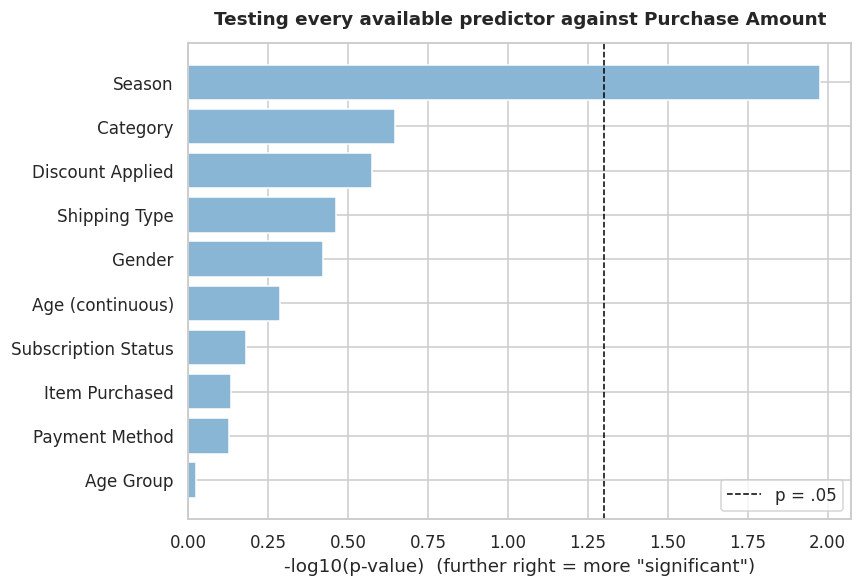

In [15]:
plot_df = results_df.copy()
plot_df["neg_log10_p"] = -np.log10(plot_df["p-value"].clip(lower=1e-12))
bar_colors = [PALETTE[4] if m != "negligible" else PALETTE[5] for m in plot_df["Magnitude"]]

plt.figure(figsize=(8, 5.5))
plt.barh(plot_df["Predictor"], plot_df["neg_log10_p"], color=bar_colors)
plt.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="p = .05")
plt.xlabel("-log10(p-value)  (further right = more \"significant\")")
plt.title("Testing every available predictor against Purchase Amount")
plt.gca().invert_yaxis()
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

n_significant = int(results_df["Significant (p<.05)"].sum())
n_negligible = int((results_df["Magnitude"] == "negligible").sum())
print(f"{n_significant} of {len(results_df)} predictors are statistically significant at p<.05.")
print(f"{n_negligible} of {len(results_df)} predictors have a negligible effect size.")


Only **Season** clears the p < .05 bar (p = 0.011) &mdash; and its effect size (eta-squared &asymp; 0.003) is still classified as *negligible*: Season explains roughly three-tenths of one percent of the variation in Purchase Amount. Every other predictor, including the ones the original notebook singled out by name &mdash; Subscription Status, Age, Gender &mdash; is both non-significant and negligible in magnitude. Put plainly: **none of the original notebook's headline conclusions survive a formal test.** Subscribers do not spend more than non-subscribers (p = 0.66); age group does not predict spend (p = 0.95); winter is not the peak season (Fall is nominally highest, and even that difference isn't practically meaningful).

Combined with the uniform $20&ndash;$100 range and near-zero skew from Section 1, the most defensible reading is that **`Purchase Amount (USD)` was generated independently of every other field in this dataset**, most likely at random within a fixed range, rather than reflecting real pricing or purchasing psychology. That has a direct business consequence: **this dataset cannot support spend-based customer segmentation, high-value-customer identification, or discount-ROI analysis on order value** &mdash; not because the *idea* is wrong, but because this particular field carries no signal to segment on. The rest of the notebook is built around the fields that do carry a real, verifiable signal.

## 5. Engagement, Subscription, and a Confound That Changes Everything

If spend doesn't vary by customer, the next natural business question is about *engagement*: who subscribes, who uses discounts, and does it matter? Section 1 already showed that `Discount Applied` and `Promo Code Used` are literally the same field recorded twice. This section checks how that field, plus `Subscription Status`, relate to the rest of the customer base &mdash; and turns up something that needs to be flagged before it's used for anything.


In [16]:
for engagement_col in ["Subscription Status", "Discount Applied"]:
    print(f"--- {engagement_col} x Gender ---")
    print(pd.crosstab(df["Gender"], df[engagement_col]), "\n")


--- Subscription Status x Gender ---
Subscription Status    No   Yes
Gender                         
Female               1248     0
Male                 1599  1053 

--- Discount Applied x Gender ---
Discount Applied    No   Yes
Gender                      
Female            1248     0
Male               975  1677 



In [17]:
gender_discount = pd.crosstab(df["Gender"], df["Discount Applied"])
chi2, p_value, dof, expected = stats.chi2_contingency(gender_discount)
n = gender_discount.sum().sum()
cramers_v = np.sqrt((chi2 / n) / min(gender_discount.shape[0] - 1, gender_discount.shape[1] - 1))
print(f"Gender x Discount Applied  ->  chi2 = {chi2:.1f}, p = {p_value:.2e}, Cramer's V = {cramers_v:.3f}")


Gender x Discount Applied  ->  chi2 = 1381.9, p = 1.76e-302, Cramer's V = 0.595


This is not a mild association &mdash; it is a **complete separation**. Every single one of the 1,248 female customer records shows *No* subscription and *No* discount/promo code. Every discount, every promo code redemption, and every subscription in the entire dataset (1,677 of them) belongs to a male customer. Cramer's V of 0.60 is a very large effect by any conventional standard, and the p-value is effectively zero.

**This should not be read as "women in this business don't use discounts."** A gender-locked pattern this exact and this total is far more consistent with how the dataset was constructed than with any real customer behavior &mdash; no real retail promotion program produces a perfectly binary split like this. It is logged here as a **data-quality flag**, with a direct practical consequence: in this dataset, `Subscription Status` and `Discount Applied` are statistically inseparable from `Gender`. Any comparison that appears to be "by subscription" or "by discount usage" is simultaneously a comparison "by gender," and the two cannot be told apart with the data available. That rules out drawing any conclusion about subscription or discount effects on their own &mdash; which, given Section 4 already showed neither one moves Purchase Amount anyway, costs the analysis little, but it would matter a great deal for any metric that *did* show a subscription effect.

In [18]:
def engagement_segment(row):
    if row["Subscription Status"] == "Yes":
        return "Subscriber\n(auto discount + promo)"
    if row["Discount Applied"] == "Yes":
        return "Non-subscriber,\ndiscount/promo user"
    return "Non-subscriber,\nfull price"

df["Engagement Segment"] = df.apply(engagement_segment, axis=1)
segment_gender = pd.crosstab(df["Engagement Segment"], df["Gender"])
segment_gender


Gender                                Female  Male
Engagement Segment                                
Non-subscriber,\ndiscount/promo user       0   624
Non-subscriber,\nfull price             1248   975
Subscriber\n(auto discount + promo)        0  1053

Previous Purchases by Engagement Segment  ->  One-way ANOVA, p = 0.154, eta-squared = 0.001 (negligible)


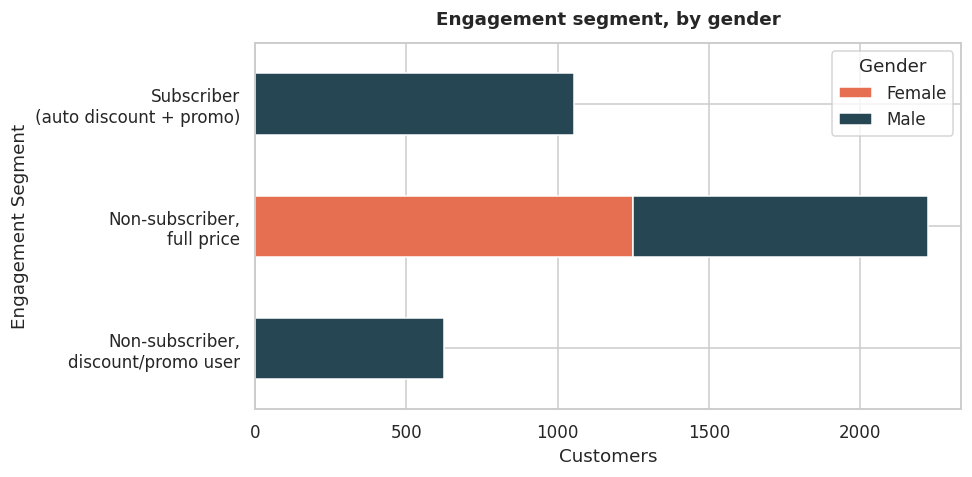

                                      customers  avg_purchase_amount  avg_previous_purchases
Engagement Segment                                                                          
Non-subscriber,\ndiscount/promo user        624                58.92                   25.17
Non-subscriber,\nfull price                2223                60.13                   25.06
Subscriber\n(auto discount + promo)        1053                59.49                   26.08

In [19]:
segment_share = df["Engagement Segment"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
segment_gender.loc[segment_share.index].plot(kind="barh", stacked=True, ax=ax,
                                              color=[PALETTE[4], PALETTE[0]])
ax.set_title("Engagement segment, by gender")
ax.set_xlabel("Customers")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

segment_profile = df.groupby("Engagement Segment", observed=True).agg(
    customers=("Customer ID", "count"),
    avg_purchase_amount=("Purchase Amount (USD)", "mean"),
    avg_previous_purchases=("Previous Purchases", "mean"),
).round(2)

tenure_test = test_group_differences(df, "Previous Purchases", "Engagement Segment")
print(f"Previous Purchases by Engagement Segment  ->  {tenure_test['Test']}, "
      f"p = {tenure_test['p-value']:.3f}, {tenure_test['Effect metric']} = {tenure_test['Effect size']} "
      f"({tenure_test['Magnitude']})")
segment_profile


Three real, well-defined segments emerge from how discount and subscription status actually combine: **full-price non-subscribers (57% of customers)**, **subscribers who automatically receive a discount and promo code (27%)**, and **non-subscribers who separately used a discount or promo code (16%)**. Consistent with Section 4, average purchase amount is flat across all three ($58.92&ndash;$60.13), and tenure (`Previous Purchases`) doesn't differ meaningfully either &mdash; engaged customers are not measurably higher-value or longer-tenured than anyone else in this data. The segmentation is a legitimate description of *how engagement mechanics are structured* in this dataset; it is not evidence that engagement drives outcomes.

## 6. Loyalty Tenure and Stated Purchase Frequency

Two fields describe how "loyal" a customer might be: `Previous Purchases`, a running count, and `Frequency of Purchases`, a self-reported label (Weekly, Monthly, Annually, etc.). If both are measuring the same underlying thing, customers who say they buy Weekly should have accumulated noticeably more previous purchases than customers who say Annually, given any reasonable tenure on the platform. That's a testable internal-consistency check, not just another cut of the data.


Previous Purchases by stated Frequency  ->  One-way ANOVA, p = 0.145, eta-squared = 0.0024 (negligible)


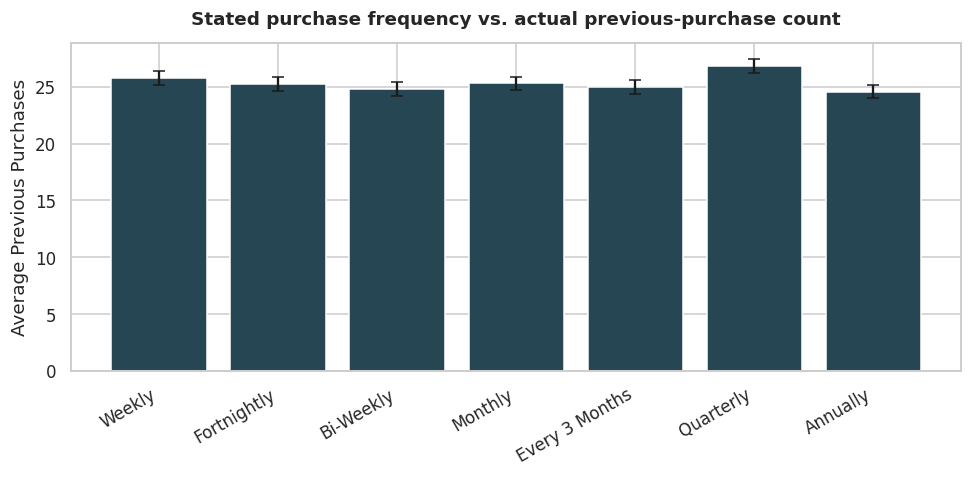

In [20]:
frequency_order = ["Weekly", "Fortnightly", "Bi-Weekly", "Monthly",
                    "Every 3 Months", "Quarterly", "Annually"]
freq_stats = df.groupby("Frequency of Purchases", observed=True)["Previous Purchases"] \
               .agg(["mean", "std", "count"]).reindex(frequency_order)

freq_test = test_group_differences(df, "Previous Purchases", "Frequency of Purchases")
print(f"Previous Purchases by stated Frequency  ->  {freq_test['Test']}, "
      f"p = {freq_test['p-value']:.3f}, {freq_test['Effect metric']} = {freq_test['Effect size']} "
      f"({freq_test['Magnitude']})")

plt.figure(figsize=(9, 4.5))
plt.bar(freq_stats.index, freq_stats["mean"],
        yerr=freq_stats["std"] / np.sqrt(freq_stats["count"]), capsize=4, color=PALETTE[0])
plt.ylabel("Average Previous Purchases")
plt.title("Stated purchase frequency vs. actual previous-purchase count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


If the label carried real signal, the bars would climb from left (Weekly) to right (Annually). They don't: the tallest bar is **Quarterly** (26.9), and Weekly (25.8) sits in the middle of the pack, barely above Annually (24.6). The ANOVA confirms there's no meaningful relationship (p = 0.145). **`Frequency of Purchases` does not appear to reflect actual purchase history in this dataset** and should not be relied on as a real cadence signal for campaign timing or churn-risk scoring without independent validation against real order dates.

`Previous Purchases` itself is close to uniform across its 1&ndash;50 range (already seen in Section 1) and, per Section 1's correlation heatmap, essentially unrelated to Age, Purchase Amount, or Review Rating. The one nominally significant relationship &mdash; a Pearson r of 0.04 (p = 0.01) between Age and Previous Purchases &mdash; is the same statistical-significance-without-practical-significance story as Season in Section 4: technically detectable with 3,900 rows, but explaining well under 1% of the variation and not something to build a strategy on.

## 7. Customer Satisfaction

`Review Rating` is the closest thing to an outcome measure in this dataset. The question worth asking is whether satisfaction tracks with anything else observed &mdash; product category, season, or fulfillment experience (shipping type) &mdash; or whether it follows the same independent pattern as everything before it.


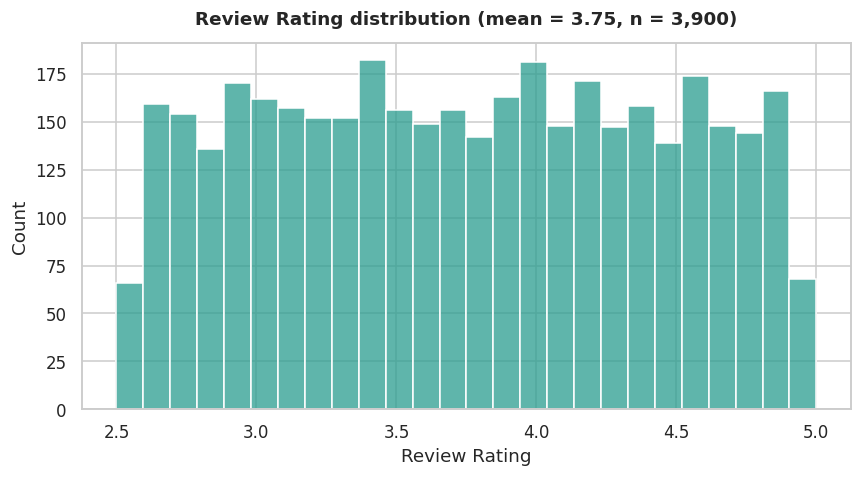

In [21]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["Review Rating"], bins=26, color=PALETTE[1], edgecolor="white")
plt.title(f"Review Rating distribution (mean = {df['Review Rating'].mean():.2f}, "
          f"n = {len(df):,})")
plt.xlabel("Review Rating")
plt.tight_layout()
plt.show()


In [22]:
rating_tests = pd.DataFrame([
    test_group_differences(df, "Review Rating", col)
    for col in ["Category", "Season", "Shipping Type", "Payment Method"]
]).sort_values("p-value").reset_index(drop=True)
rating_tests


        Predictor           Test  Statistic   p-value Effect metric  Effect size   Magnitude  Significant (p<.05)
0   Shipping Type  One-way ANOVA      2.353  0.038365   eta-squared       0.0030  negligible                 True
1        Category  One-way ANOVA      1.740  0.156579   eta-squared       0.0013  negligible                False
2          Season  One-way ANOVA      1.696  0.165698   eta-squared       0.0013  negligible                False
3  Payment Method  One-way ANOVA      0.865  0.503791   eta-squared       0.0011  negligible                False

Ratings run from 2.5 to 5.0 in a roughly uniform spread with a mean of 3.75. Of the four purchase-context variables tested, only **Shipping Type** reaches p < .05 (p = 0.038) &mdash; and its effect size is again negligible, the gap between the highest- and lowest-rated shipping method amounting to about 0.11 points on a scale with a standard deviation of 0.72. Category, Season, and Payment Method show no relationship with satisfaction at all. **By this measure, customer satisfaction in this dataset is unrelated to what was bought, when, or how it shipped** &mdash; a genuinely useful negative result: it means there's no single fulfillment or assortment lever visible here that would obviously move satisfaction scores, and any future customer-experience investigation should look outside these fields (e.g. at service interactions or product-specific complaints, which this dataset doesn't capture).

## 8. What This Data Cannot Tell Us

Every finding above is backed by a test on the actual data. This section is the deliberate counterpart: a plain account of the questions this dataset structurally cannot answer, so nothing below Section 9 is read as more conclusive than it is.

- **No transaction timeline.** One row per customer, no order dates, no timestamps anywhere. `Previous Purchases` is a static count and `Frequency of Purchases` is a self-reported label that Section 6 showed doesn't track actual purchase counts. **True purchase cadence, recency, retention, churn, and any trend or seasonality over calendar time are all out of reach** &mdash; the `Season` column is a per-customer attribute, not a real sequence of observations across time.
- **No cost or margin data.** Only the customer-facing `Purchase Amount (USD)` is available. **Profit, margin, discount ROI, and customer lifetime value cannot be calculated** and are not approximated anywhere in this notebook.
- **`Purchase Amount (USD)` itself shows no relationship to any other field** (Section 4) and is capped in an unusually narrow, non-skewed $20&ndash;$100 range (Section 1). The most defensible interpretation is that it was generated independently of the rest of the record. It should not be trusted as a real economic signal without validation against the original source system.
- **`Discount Applied` and `Promo Code Used` are perfect duplicates** (Section 1), and `Subscription Status`/`Discount Applied` are completely confounded with `Gender` (Section 5, Cramer's V = 0.60, every female record shows no engagement of any kind). This pattern is far more consistent with a data-generation artifact than a real promotional program, and it means gender cannot be statistically separated from "engagement" anywhere in this dataset.
- **Single snapshot, no acquisition or non-purchaser data.** Every record is a customer who purchased; there is no visibility into site visits, cart abandonment, or non-converting traffic, so **conversion rate cannot be measured**.
- **Geographic and item-level demand look statistically uniform** (Sections 2 and 3), which limits how much this specific 3,900-row sample can say about real regional or product-level demand differences at a larger scale.

None of this is a criticism of the dataset for its actual purpose (practicing exploratory analysis) &mdash; it is the standard due diligence a business would expect before this analysis is used to justify a real budget decision.


## 9. Business Recommendations

Each recommendation below traces directly back to a specific, tested finding &mdash; no recommendation here is generic advice unconnected to the evidence.

**1. Stop using order value as a segmentation or targeting variable on this dataset.**
&nbsp;&nbsp;*Evidence:* every one of 10 tested predictors of Purchase Amount is either non-significant or negligible in effect size (Section 4).
&nbsp;&nbsp;*Implication:* any "high-value customer" list, spend-based tier, or discount-ROI claim built on this field would be built on noise.
&nbsp;&nbsp;*Action:* before relying on order value for targeting, validate the field against the source transaction system; if confirmed synthetic/randomized, exclude it from segmentation models entirely.

**2. Audit the data pipeline behind `Subscription Status`, `Discount Applied`, and `Promo Code Used` before using any of them in a gender-related analysis.**
&nbsp;&nbsp;*Evidence:* 100% of female customer records show no subscription or discount activity of any kind; Cramer's V = 0.60 with `Gender` (Section 5).
&nbsp;&nbsp;*Implication:* as recorded, these fields cannot distinguish a gender effect from an engagement effect, and the pattern is too clean to be organic customer behavior.
&nbsp;&nbsp;*Action:* trace these fields back to their source system to confirm whether this reflects a real program gap or a data-collection/labeling error before drawing any marketing conclusion from them.

**3. Keep assortment and marketing broadly cross-category rather than gender-segmented.**
&nbsp;&nbsp;*Evidence:* category mix is statistically indistinguishable by gender (chi-square p = 0.90); item-level tilts by gender are mild, not divides (Section 3).
&nbsp;&nbsp;*Implication:* a gender-based product-marketing split would not be supported by actual purchase behavior in this data.
&nbsp;&nbsp;*Action:* if a segmented marketing strategy is wanted, base it on category-level (not gender-level) engagement, or gather attitudinal data this transactional dataset doesn't contain.

**4. Do not prioritize specific states or regions based on this dataset.**
&nbsp;&nbsp;*Evidence:* customer counts and total spend per state are both close to uniform (coefficient of variation &asymp; 0.10; Section 2).
&nbsp;&nbsp;*Implication:* there is no demand concentration here to justify a regional expansion or region-targeted campaign.
&nbsp;&nbsp;*Action:* if regional strategy is a genuine priority, it needs a dataset built for that purpose (e.g. larger, longitudinal, with marketing-spend-by-region attached).

**5. Invest in the data that's actually missing before attempting retention, CLV, or profitability analysis.**
&nbsp;&nbsp;*Evidence:* no timestamps, no cost/margin data, no non-purchaser data anywhere in the dataset (Section 8).
&nbsp;&nbsp;*Implication:* these are the structural gaps, not analytical gaps &mdash; no amount of additional modeling on this dataset as-is will produce a trustworthy churn, LTV, or ROI figure.
&nbsp;&nbsp;*Action:* prioritize capturing order-level records with timestamps and cost data; that single change would unlock most of what this notebook had to rule out.
